week 1

 Environment Setup

In [5]:
!pip install -q datasets transformers torch torchvision matplotlib

In [6]:

# setting up th environment and importing necessary libraries
import torch
import numpy as np
import matplotlib.pyplot as plt


Loading the DESI Legacy Survey Dataset

In [7]:
from datasets import load_dataset
data = load_dataset(
    "MultimodalUniverse/legacysurvey",
    split="train",
    streaming=True)

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

In [10]:
print(data)

IterableDataset({
    features: ['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'],
    num_shards: 165
})


In [11]:
print("Trying to fetch first sample...")

sample = next(iter(data))

print("Sample received!")
print(type(sample))
print(sample.keys())

Trying to fetch first sample...
Sample received!
<class 'dict'>
dict_keys(['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'])


Dataset Exploration

In [12]:
print(data.features)

{'image': {'band': List(Value('string')), 'flux': List(Array2D(shape=(160, 160), dtype='float32')), 'mask': List(Array2D(shape=(160, 160), dtype='bool')), 'ivar': List(Array2D(shape=(160, 160), dtype='float32')), 'psf_fwhm': List(Value('float32')), 'scale': List(Value('float32'))}, 'blobmodel': Image(mode=None, decode=True), 'rgb': Image(mode=None, decode=True), 'object_mask': Image(mode=None, decode=True), 'catalog': {'FLUX_G': List(Value('float32')), 'FLUX_R': List(Value('float32')), 'FLUX_I': List(Value('float32')), 'FLUX_Z': List(Value('float32')), 'TYPE': List(Value('float32')), 'SHAPE_R': List(Value('float32')), 'SHAPE_E1': List(Value('float32')), 'SHAPE_E2': List(Value('float32')), 'X': List(Value('float32')), 'Y': List(Value('float32'))}, 'EBV': Value('float32'), 'FLUX_G': Value('float32'), 'FLUX_R': Value('float32'), 'FLUX_I': Value('float32'), 'FLUX_Z': Value('float32'), 'FLUX_W1': Value('float32'), 'FLUX_W2': Value('float32'), 'FLUX_W3': Value('float32'), 'FLUX_W4': Value('f

In [13]:
print(sample["image"]["band"])

['des-g', 'des-r', 'des-i', 'des-z']


In [14]:
print(len(sample["image"]["flux"]))

4


In [16]:
for i, band in enumerate(sample["image"]["band"]):
    print(i, band, type(sample["image"]["flux"][i]))

0 des-g <class 'list'>
1 des-r <class 'list'>
2 des-i <class 'list'>
3 des-z <class 'list'>


In [17]:
for i, band in enumerate(sample["image"]["band"]):
    flux = sample["image"]["flux"][i]
    print(i, band, len(flux), len(flux[0]))

0 des-g 160 160
1 des-r 160 160
2 des-i 160 160
3 des-z 160 160


In [18]:
import numpy as np

flux = np.array(sample["image"]["flux"][i])
print(flux.shape)

(160, 160)


 Visualizing DESI Galaxy Images

In [19]:
import numpy as np

bands = {}

for i, band in enumerate(sample["image"]["band"]):
    bands[band] = np.array(sample["image"]["flux"][i])

for band, image in bands.items():
    print(band, image.shape, image.dtype)

des-g (160, 160) float64
des-r (160, 160) float64
des-i (160, 160) float64
des-z (160, 160) float64


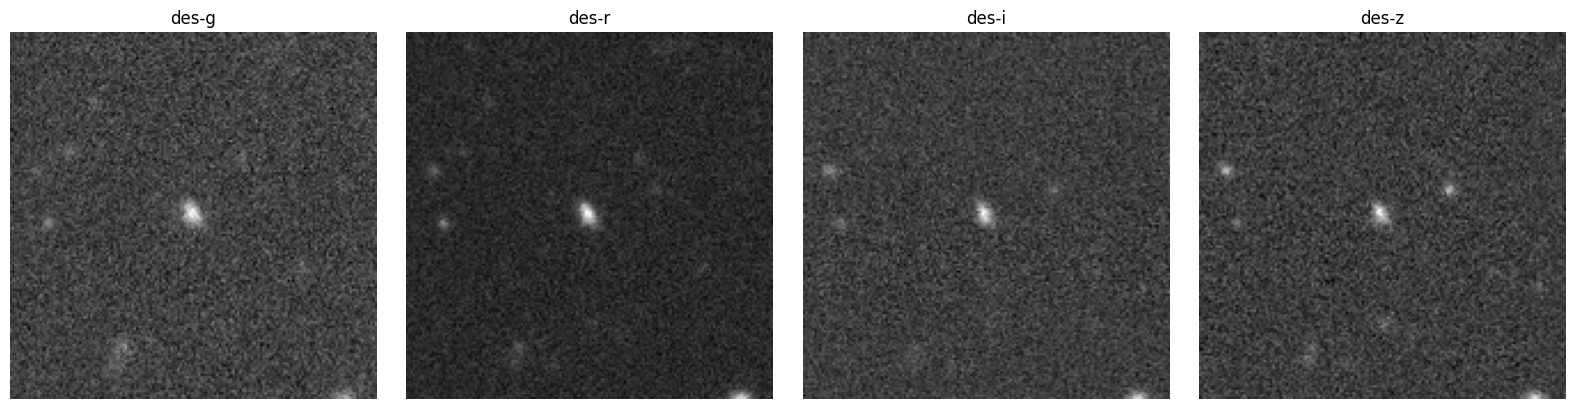

In [22]:
import matplotlib.pyplot as plt

band_names = ["des-g", "des-r", "des-i", "des-z"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, band in zip(axes, band_names):
    ax.imshow(bands[band], cmap="gray")
    ax.set_title(band)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
print(sample.keys())

dict_keys(['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'])


In [24]:
print(sample["catalog"].keys())

dict_keys(['FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'TYPE', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'X', 'Y'])


In [25]:
print(sample["object_id"])

b'0421p022-7410'


Now let's move to DINOv2

In [26]:
print(type(sample["rgb"]))
print(sample["rgb"])

<class 'PIL.PngImagePlugin.PngImageFile'>
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x160 at 0x7CE08C653230>


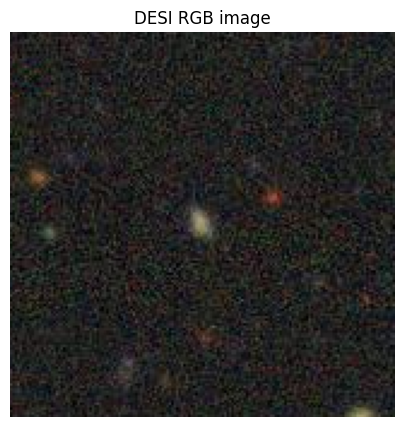

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(sample["rgb"])
plt.axis("off")
plt.title("DESI RGB image")
plt.show()

In [28]:
!pip install -q transformers

Loading the Pretrained DINOv2 Model

In [29]:
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-small")
model = AutoModel.from_pretrained("facebook/dinov2-small")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [30]:
model.eval()

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((384,), eps=1e-06,

Image Preprocessing

In [31]:
image = sample["rgb"]

inputs = processor(images=image, return_tensors="pt")

print(inputs["pixel_values"].shape)

torch.Size([1, 3, 224, 224])


DINOv2 Inference

In [32]:
with torch.no_grad():
    outputs = model(**inputs)

print(outputs.last_hidden_state.shape)

torch.Size([1, 257, 384])


Extracting the CLS Token

In [33]:
cls_token = outputs.last_hidden_state[:, 0, :]

print(cls_token.shape)

torch.Size([1, 384])


Extracting Patch Tokens

In [35]:
patch_tokens = outputs.last_hidden_state[:, 1:, :]

print(patch_tokens.shape)


torch.Size([1, 256, 384])


In [36]:
cls_token = outputs.last_hidden_state[:, 0, :]
print("CLS token:", cls_token.shape)

CLS token: torch.Size([1, 384])


In [37]:
patch_tokens = outputs.last_hidden_state[:, 1:, :]
print("Patch tokens:", patch_tokens.shape)

Patch tokens: torch.Size([1, 256, 384])


Patch Embedding Exploration

In [38]:
patch_magnitude = patch_tokens.norm(dim=-1)

print(patch_magnitude.shape)

torch.Size([1, 256])


 Reshaping Patch Embeddings into a 16×16 Grid

In [39]:
patch_grid = patch_magnitude[0].reshape(16, 16)

print(patch_grid.shape)

torch.Size([16, 16])


 DINOv2 Patch Embedding Magnitude Visualization

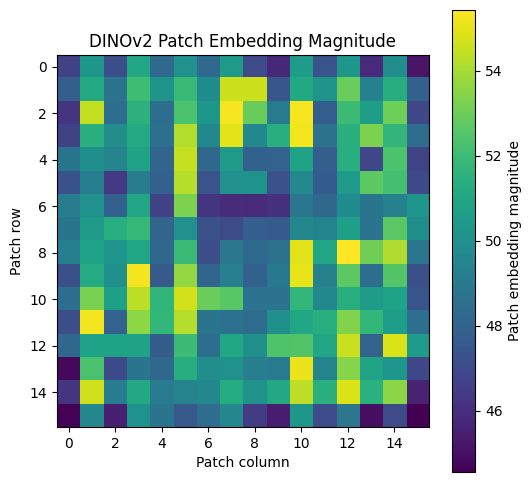

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(patch_grid.cpu().numpy(), cmap="viridis")
plt.colorbar(label="Patch embedding magnitude")
plt.title("DINOv2 Patch Embedding Magnitude")
plt.xlabel("Patch column")
plt.ylabel("Patch row")
plt.show()

Galaxy Image and DINOv2 Patch Representation

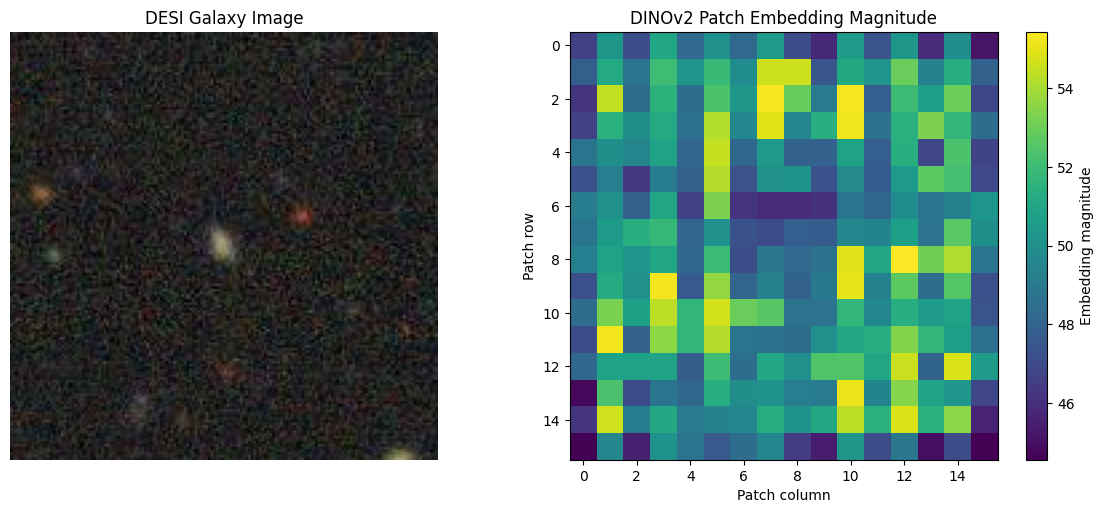

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)
axes[0].set_title("DESI Galaxy Image")
axes[0].axis("off")

im = axes[1].imshow(patch_grid.cpu().numpy(), cmap="viridis")
axes[1].set_title("DINOv2 Patch Embedding Magnitude")
axes[1].set_xlabel("Patch column")
axes[1].set_ylabel("Patch row")
fig.colorbar(im, ax=axes[1], label="Embedding magnitude")

plt.tight_layout()
plt.show()

In [ ]:
S